# Evaluating the GAN

A classifier has accuracy; an autoencoder has reconstruction error. A GAN has
**neither** — no labels, no target image. So how do you know it is any good?

We can do visual inspection for:

| Question | Are the samples… | Tool |
|---|---|---|
| **Quality** | …sharp and digit-like? | sample grid |
| **Generalization** | …novel, not copied from training data? | latent interpolation + nearest-neighbour |
| **Coverage** | …spanning all 10 digits, not just a few? | digit-class histogram |

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1)
print(f"Device: {device}")

Z_DIM, IMG_DIM = 64, 28 * 28

# Generator definition must match 01_GAN_MNIST.ipynb exactly
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),  nn.BatchNorm1d(256),  nn.LeakyReLU(0.2),
            nn.Linear(256, 512),    nn.BatchNorm1d(512),  nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),   nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, IMG_DIM),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


G = Generator().to(device)
G.load_state_dict(torch.load("gan_mnist_generator.pth", map_location=device))
G.eval()
print("Loaded gan_mnist_generator.pth")

Device: cuda
Loaded gan_mnist_generator.pth


## 1. Quality

draw 64 fresh noise vectors and look. Most cells should hold a clean, recognizable digit. 

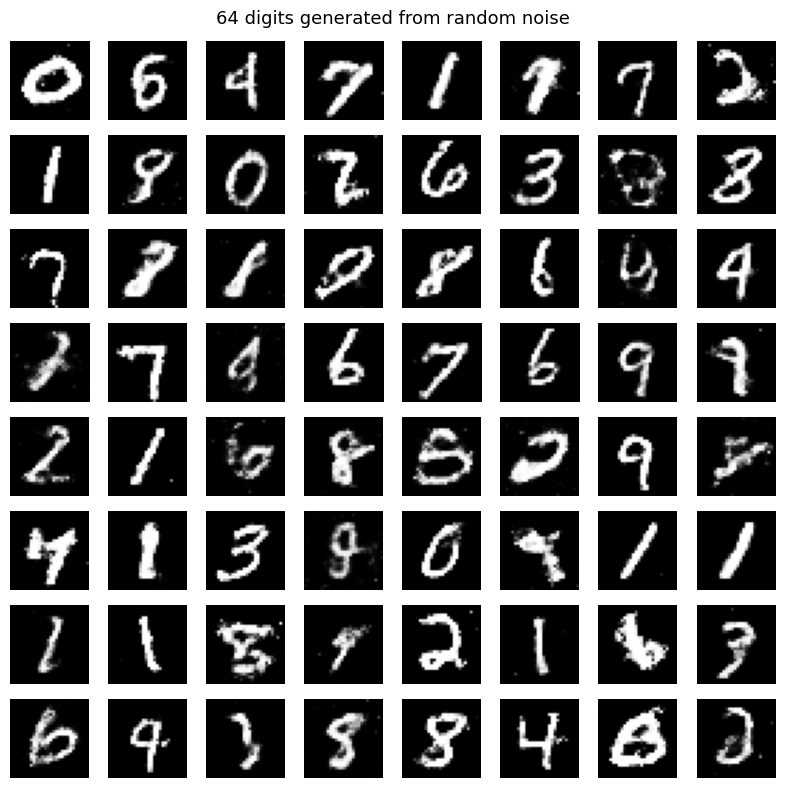

In [3]:
with torch.no_grad():
    z = torch.randn(64, Z_DIM, device=device)
    fake = G(z).cpu()
fake = (fake + 1) / 2     # [-1, 1] -> [0, 1]

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for ax, img in zip(axes.flat, fake):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("64 digits generated from random noise", fontsize=13)
plt.tight_layout(); plt.show()

## 2. Generalization

Pick two noise vectors, walk a straight line between them, and decode each step

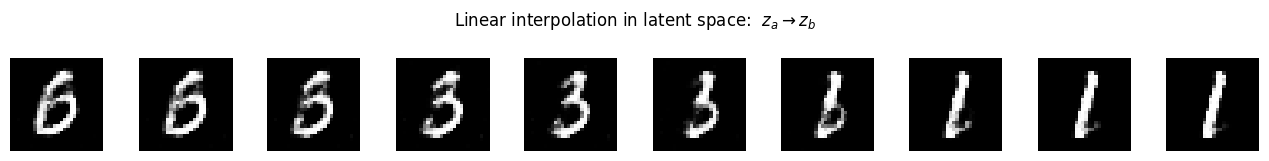

In [4]:
STEPS = 10
z_a = torch.randn(1, Z_DIM, device=device)
z_b = torch.randn(1, Z_DIM, device=device)
alphas = torch.linspace(0, 1, STEPS, device=device).view(-1, 1)
z_interp = (1 - alphas) * z_a + alphas * z_b

with torch.no_grad():
    morph = G(z_interp).cpu()
morph = (morph + 1) / 2

fig, axes = plt.subplots(1, STEPS, figsize=(STEPS * 1.3, 1.6))
for ax, img in zip(axes, morph):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle(r"Linear interpolation in latent space:  $z_a \rightarrow z_b$", fontsize=12)
plt.tight_layout(); plt.show()

## 3. Coverage — are all 10 digits represented?

**Mode collapse** is a GAN-specific failure where the generator finds a few outputs
that reliably fool $D$ and stops bothering with the rest

In [ ]:
# Real training images
real_ds = datasets.MNIST(root="./data/", train=True, download=True,
                         transform=transforms.ToTensor())
real_imgs = real_ds.data.float().to(device) / 255.0       # (60000, 28, 28), [0, 1]
real_flat = real_imgs.view(real_imgs.size(0), -1)

clf_loader = DataLoader(real_ds, batch_size=256, shuffle=True)

clf = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 -> 7
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)

clf.train()
for epoch in range(2):
    correct = total = 0
    for x, y in clf_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = clf(x)
        F.cross_entropy(out, y).backward()
        opt.step()
        correct += (out.argmax(1) == y).sum().item(); total += y.size(0)
    print(f"classifier epoch {epoch + 1}: train acc {correct / total:.3f}")
clf.eval()
print("Classifier ready — accurate enough to label generated digits.")

classifier epoch 1: train acc 0.880
classifier epoch 2: train acc 0.967
Classifier ready — accurate enough to label generated digits.


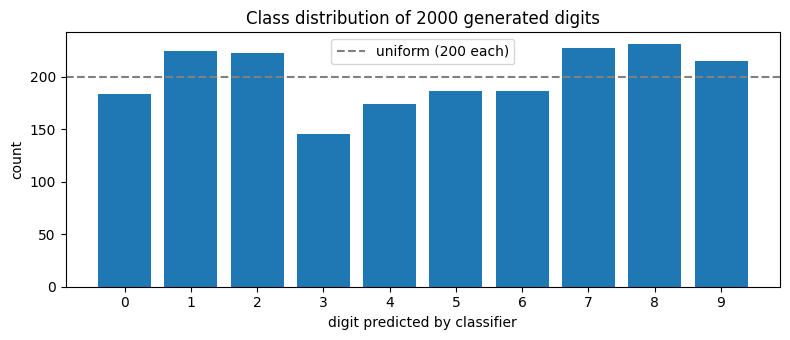

min/max class ratio: 0.63  (1.0 = perfectly uniform, near 0 = mode collapse)


In [6]:
# Label 2,000 generated digits and tally the predicted classes
preds = []
with torch.no_grad():
    for _ in range(8):
        gen = G(torch.randn(250, Z_DIM, device=device))
        gen = (gen + 1) / 2                       # match classifier's [0, 1] input
        preds.append(clf(gen).argmax(1).cpu())
preds = torch.cat(preds)
counts = torch.bincount(preds, minlength=10)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(10), counts.numpy())
ax.axhline(len(preds) / 10, ls="--", c="gray", label="uniform (200 each)")
ax.set_xticks(range(10))
ax.set_xlabel("digit predicted by classifier"); ax.set_ylabel("count")
ax.set_title(f"Class distribution of {len(preds)} generated digits")
ax.legend()
plt.tight_layout(); plt.show()

ratio = counts.min().item() / counts.max().item()
print(f"min/max class ratio: {ratio:.2f}  "
      f"(1.0 = perfectly uniform, near 0 = mode collapse)")

## Takeaway

The vanilla GAN should generate sharp samples, smooth interpolation and reasonably balanced class coverage.